### Problem1

In [1]:
import numpy as np
import numpy.random as nr
import matplotlib.pyplot as plt
from scipy.stats.qmc import PoissonDisk
'''
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"device: {device}")
'''

'\nimport torch\nimport torch.nn as nn\nimport torch.optim as optim\nfrom torch.utils.data import Dataset, DataLoader\n\nif torch.cuda.is_available():\n    device = "cuda"\nelif torch.backends.mps.is_available():\n    device = "mps"\nelse:\n    device = "cpu"\n\nprint(f"device: {device}")\n'

In [2]:
h = 0.4 # Å, pixel size
N = 128 # pixel, system size
L = N*h # Å, sistem size
d = 2 # Å, minimum interatomic distance

print(N, L)

128 51.2


In [ ]:
class imageGenerator:
    def __init__(self):
        self.h = 0.4 # Å, pixel size
        self.N = 128 # pixel, system size
        self.L = self.N*self.h # Å, sistem size
        self.d = 2 # Å, minimum interatomic distance

        x = np.arange(0, self.L, self.h)
        y = np.arange(0, self.L, self.h)
        self.X, self.Y = np.meshgrid(x, y)
        c = self.L/2 # center
        self.limitCircle = ((self.X-c)**2 + (self.Y-c)**2) < 20**2 # circlular limit


    def amorphous(self, minArea=5000, maxArea=11000):
        mask = np.zeros((self.N, self.N), dtype=float)
        go = True

        while go:
            x0 = nr.rand()*self.L
            y0 = nr.rand()*self.L
            r = nr.rand()*(10-5) + 5
            circle = ((self.X-x0)**2 + (self.Y-y0)**2 ) < r**2

            ix0 = np.clip(int(x0/self.h), 0, self.N-1)
            iy0 = np.clip(int(y0/self.h), 0, self.N-1)

            if np.any(circle & (~self.limitCircle)):
                continue
            
            elif (np.sum(mask) > 0) and mask[iy0, ix0] == False:
                continue

            else:
                mask += circle
                mask = np.clip(mask, 0, 1)

            area = np.sum(mask)

            if area > minArea:
                if np.random.uniform() > 0.5:
                    go = False
                elif area > maxArea:
                    go = False     
                    
        rng = np.random.default_rng()
        engine = PoissonDisk(d=2, radius=self.d/self.L, rng=rng)
        sample = engine.random(420)*self.L

        ix = np.clip((sample[:, 0]/self.h).astype(int), 0, self.N-1)
        iy = np.clip((sample[:, 1]/self.h).astype(int), 0, self.N-1)
        inside = mask[iy, ix] > 0
        self.sample = sample[inside]
        self.mask = mask

    def makeImage(self):
        return ...

system size in pixel = (128, 128)
area of mask = 5477.0
number of atoms = (129, 2)
sampled density = [0.02355304]
target density = 0.05092958178940651


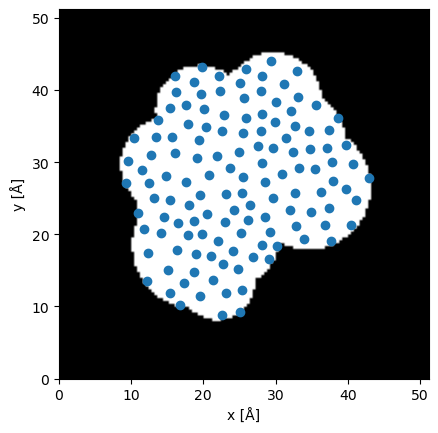

In [38]:
im = imageGenerator()
im.amorphous()

print(f"system size in pixel = {np.shape(im.mask)}")
print(f"area of mask = {np.sum(im.mask)}")
print(f"number of atoms = {np.shape(im.sample)}")
print(f"sampled density = {np.shape(im.sample[:, 0])/np.sum(im.mask)}")
print(f"target density = {1/(np.pi*2.5*2.5)}")

plt.imshow(im.mask, origin="lower", extent=[0, L, 0, L], cmap='binary_r')
plt.scatter(im.sample[:, 0], im.sample[:, 1])
plt.xlabel('x [Å]')
plt.ylabel('y [Å]')

plt.show()
